# Understanding JMFFT
## Discrete Fourier Transform (DFT)
*Adapted from* https://jakevdp.github.io/blog/2013/08/28/understanding-the-fft/

$$X_{k} = \sum_{n=0}^{N-1}x_{n} \cdot e^{-{\frac { \mathbb{j}~2\pi }{N}}kn}~~~~;~k = 0, ..., \frac n 2$$

The transformation from $x_n \to X_k$ is a translation from configuration space to frequency space. DFT converts a finite sequence of equally-spaced samples of a function into a same-length sequence of equally-spaced samples of the Discrete-Time Fourier transform (DTFT),  which is a complex-valued function of frequency. The interval at which the DTFT is sampled is the reciprocal of the duration of the input sequence. Is therefore said to be a frequency domain representation of the original input sequence.

Taking a look at the DFT expression above, we see that it is nothing more than a straightforward linear operation: a matrix-vector multiplication of $\vec{x}$,

$$\vec{X} = M \cdot \vec{x}$$

with the matrix $M$ given by

$$M_{kn} = e^{-{\frac {\mathbb{j}~2\pi }{N}}kn}$$

NumPy resources
* **asarray** - Convert the input to an array. Input data in any form that can be converted to an array. This includes lists, lists of tuples, tuples, tuples of tuples, tuples of lists and ndarrays.
* **arange** - Return evenly spaced values within a given interval.

Create random data

In [1]:
import numpy as np
np.set_printoptions(precision=2, linewidth=70)
# x = np.random.random(6)
# np.save("data", x)
x = np.load("data.npy")
x

array([0.54, 0.05, 0.19, 0.98, 0.16, 0.26])

In [2]:
N = x.shape[0]
N

6

In [3]:
n = np.arange(N)
n

array([0, 1, 2, 3, 4, 5])

In [4]:
k = n.reshape((N, 1))
k

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5]])

In [5]:
k * n

array([[ 0,  0,  0,  0,  0,  0],
       [ 0,  1,  2,  3,  4,  5],
       [ 0,  2,  4,  6,  8, 10],
       [ 0,  3,  6,  9, 12, 15],
       [ 0,  4,  8, 12, 16, 20],
       [ 0,  5, 10, 15, 20, 25]])

In [6]:
2 * np.pi * k * n / N

array([[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  1.05,  2.09,  3.14,  4.19,  5.24],
       [ 0.  ,  2.09,  4.19,  6.28,  8.38, 10.47],
       [ 0.  ,  3.14,  6.28,  9.42, 12.57, 15.71],
       [ 0.  ,  4.19,  8.38, 12.57, 16.76, 20.94],
       [ 0.  ,  5.24, 10.47, 15.71, 20.94, 26.18]])

In [7]:
-1j * 2 * np.pi * k * n / N

array([[0. +0.j  , 0. +0.j  , 0. +0.j  , 0. +0.j  , 0. +0.j  ,
        0. +0.j  ],
       [0. +0.j  , 0. -1.05j, 0. -2.09j, 0. -3.14j, 0. -4.19j,
        0. -5.24j],
       [0. +0.j  , 0. -2.09j, 0. -4.19j, 0. -6.28j, 0. -8.38j,
        0.-10.47j],
       [0. +0.j  , 0. -3.14j, 0. -6.28j, 0. -9.42j, 0.-12.57j,
        0.-15.71j],
       [0. +0.j  , 0. -4.19j, 0. -8.38j, 0.-12.57j, 0.-16.76j,
        0.-20.94j],
       [0. +0.j  , 0. -5.24j, 0.-10.47j, 0.-15.71j, 0.-20.94j,
        0.-26.18j]])

In [8]:
M = np.exp(-1j * 2 * np.pi * k * n / N)
M

array([[ 1. +0.00e+00j,  1. +0.00e+00j,  1. +0.00e+00j,
         1. +0.00e+00j,  1. +0.00e+00j,  1. +0.00e+00j],
       [ 1. +0.00e+00j,  0.5-8.66e-01j, -0.5-8.66e-01j,
        -1. -1.22e-16j, -0.5+8.66e-01j,  0.5+8.66e-01j],
       [ 1. +0.00e+00j, -0.5-8.66e-01j, -0.5+8.66e-01j,
         1. +2.45e-16j, -0.5-8.66e-01j, -0.5+8.66e-01j],
       [ 1. +0.00e+00j, -1. -1.22e-16j,  1. +2.45e-16j,
        -1. -3.67e-16j,  1. +4.90e-16j, -1. -2.39e-15j],
       [ 1. +0.00e+00j, -0.5+8.66e-01j, -0.5-8.66e-01j,
         1. +4.90e-16j, -0.5+8.66e-01j, -0.5-8.66e-01j],
       [ 1. +0.00e+00j,  0.5+8.66e-01j, -0.5+8.66e-01j,
        -1. -2.39e-15j, -0.5-8.66e-01j,  0.5-8.66e-01j]])

In [9]:
M.real

array([[ 1. ,  1. ,  1. ,  1. ,  1. ,  1. ],
       [ 1. ,  0.5, -0.5, -1. , -0.5,  0.5],
       [ 1. , -0.5, -0.5,  1. , -0.5, -0.5],
       [ 1. , -1. ,  1. , -1. ,  1. , -1. ],
       [ 1. , -0.5, -0.5,  1. , -0.5, -0.5],
       [ 1. ,  0.5, -0.5, -1. , -0.5,  0.5]])

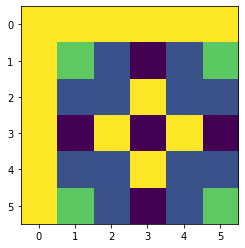

In [10]:
import matplotlib.pyplot as plt
plt.imshow(M.real)
# plt.grid(True)
plt.show()

In [23]:
t = np.dot(M, x)
t

array([ 2.18+0.00e+00j, -0.46+1.58e-01j,  1.19+2.11e-01j, -0.4 -8.69e-16j,  1.19-2.11e-01j, -0.46-1.58e-01j])

Double-check the result by comparing to numpy's built-in FFT function

In [22]:
u = np.fft.fft(x)
u

array([ 2.18+0.j  , -0.46+0.16j,  1.19+0.21j, -0.4 +0.j  ,  1.19-0.21j, -0.46-0.16j])

In [40]:
np.allclose(t, u)

True

### A vectorized, non-recursive version of the Cooley-Tukey FFT

In [9]:
import numpy as np
np.set_printoptions(precision=2, linewidth=70)
# x = np.random.random(64)
# np.save("data2", x)
x2 = np.load("data2.npy")
# np.savetxt("data2.csv", x2)
x2

array([0.86, 0.28, 0.68, 0.01, 0.78, 0.59, 0.88, 0.83, 0.27, 0.3 ,
       0.86, 0.37, 0.85, 0.76, 0.04, 0.33, 0.04, 0.6 , 0.89, 0.86,
       0.37, 0.93, 0.86, 0.92, 0.08, 0.54, 0.44, 0.49, 0.78, 0.78,
       0.29, 0.89, 0.35, 0.89, 0.27, 0.82, 0.61, 0.78, 0.82, 0.46,
       0.23, 0.02, 0.84, 0.16, 0.53, 0.06, 0.58, 0.34, 0.71, 0.6 ,
       0.32, 0.64, 0.68, 0.66, 0.44, 0.83, 0.49, 0.17, 0.15, 0.47,
       0.24, 0.3 , 0.63, 0.34])

In [10]:
N2 = x2.shape[0]
N2

64

In [11]:
N_min = min(N2, 32)    # Return the lowest number
N_min

32

In [12]:
n2 = np.arange(N_min)
n2

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,
       15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
       30, 31])

In [13]:
k2 = n2[:, None]
k2

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13],
       [14],
       [15],
       [16],
       [17],
       [18],
       [19],
       [20],
       [21],
       [22],
       [23],
       [24],
       [25],
       [26],
       [27],
       [28],
       [29],
       [30],
       [31]])

In [14]:
M2 = np.exp(-2j * np.pi * n2 * k2 / N_min)
M2

array([[ 1.  +0.j  ,  1.  +0.j  ,  1.  +0.j  , ...,  1.  +0.j  ,
         1.  +0.j  ,  1.  +0.j  ],
       [ 1.  +0.j  ,  0.98-0.2j ,  0.92-0.38j, ...,  0.83+0.56j,
         0.92+0.38j,  0.98+0.2j ],
       [ 1.  +0.j  ,  0.92-0.38j,  0.71-0.71j, ...,  0.38+0.92j,
         0.71+0.71j,  0.92+0.38j],
       ...,
       [ 1.  +0.j  ,  0.83+0.56j,  0.38+0.92j, ..., -0.2 -0.98j,
         0.38-0.92j,  0.83-0.56j],
       [ 1.  +0.j  ,  0.92+0.38j,  0.71+0.71j, ...,  0.38-0.92j,
         0.71-0.71j,  0.92-0.38j],
       [ 1.  +0.j  ,  0.98+0.2j ,  0.92+0.38j, ...,  0.83-0.56j,
         0.92-0.38j,  0.98-0.2j ]])

In [15]:
M2.shape

(32, 32)

In [16]:
T2 = np.dot(M2, x2.reshape((N_min, -1)))
T2

array([[16.86+0.00e+00j, 17.03+0.00e+00j],
       [ 0.84+4.26e-02j, -2.16-2.10e+00j],
       [ 0.19-1.62e+00j, -0.13+2.03e+00j],
       [ 1.14-1.50e+00j, -2.39-4.80e-01j],
       [-0.23-9.75e-01j,  1.13-2.45e+00j],
       [ 0.56+5.52e-02j, -1.15+8.65e-01j],
       [ 1.16+5.19e-01j, -0.07+7.49e-01j],
       [ 1.98-1.23e+00j, -0.34-1.04e-01j],
       [-1.79+9.66e-02j, -1.47+1.11e+00j],
       [-0.1 +1.19e+00j, -0.08+1.00e+00j],
       [-0.2 +1.67e+00j, -0.03+8.19e-01j],
       [ 1.26+5.13e-01j,  1.36-2.59e-01j],
       [ 2.01-8.99e-01j,  1.54-3.52e-01j],
       [-2.21+6.31e-01j, -0.02+2.33e-01j],
       [ 0.69-7.66e-01j,  0.13+5.74e-01j],
       [ 0.63-1.26e+00j, -0.11+8.59e-01j],
       [-1.12-7.30e-15j, -0.53-9.74e-15j],
       [ 0.63+1.26e+00j, -0.11-8.59e-01j],
       [ 0.69+7.66e-01j,  0.13-5.74e-01j],
       [-2.21-6.31e-01j, -0.02-2.33e-01j],
       [ 2.01+8.99e-01j,  1.54+3.52e-01j],
       [ 1.26-5.13e-01j,  1.36+2.59e-01j],
       [-0.2 -1.67e+00j, -0.03-8.19e-01j],
       [-0.

In [17]:
T2.shape

(32, 2)

In [17]:
while T2.shape[0] < N2:
    X_even = T2[:, :T2.shape[1] // 2 ]
    X_odd = T2[:, T2.shape[1] // 2 : ]
    factor = (np.exp(-1j * np.pi * np.arange(T2.shape[0]) /
                     T2.shape[0])[:, None])
    T2 = (np.vstack([X_even + factor * X_odd, X_even -
                     factor * X_odd]))
T2

array([[33.88+0.j  ],
       [-1.52-1.84j],
       [ 0.45+0.4j ],
       [-1.28-1.27j],
       [-0.12-3.67j],
       [-0.05+1.36j],
       [ 1.52+1.18j],
       [ 1.65-1.1j ],
       [-2.05+1.92j],
       [ 0.62+1.89j],
       [ 0.46+2.15j],
       [ 1.68-0.81j],
       [ 2.27-2.45j],
       [-1.99+0.72j],
       [ 1.28-0.78j],
       [ 1.47-1.07j],
       [-1.12+0.53j],
       [-0.21+1.46j],
       [ 0.1 +0.75j],
       [-2.43-0.55j],
       [ 1.74-0.66j],
       [ 0.85-1.84j],
       [-0.87-1.19j],
       [-0.82-0.49j],
       [-1.54+1.72j],
       [ 2.3 +1.36j],
       [ 0.81+0.14j],
       [ 1.16+1.25j],
       [-0.33-1.72j],
       [ 3.57+1.74j],
       [-0.08+3.63j],
       [ 3.19-1.93j],
       [-0.17+0.j  ],
       [ 3.19+1.93j],
       [-0.08-3.63j],
       [ 3.57-1.74j],
       [-0.33+1.72j],
       [ 1.16-1.25j],
       [ 0.81-0.14j],
       [ 2.3 -1.36j],
       [-1.54-1.72j],
       [-0.82+0.49j],
       [-0.87+1.19j],
       [ 0.85+1.84j],
       [ 1.74+0.66j],
       [-2

In [19]:
T2.shape

(64, 1)

* ravel() returns contiguous flattened array(1D array with all the input-array elements and with the same type as it)

In [18]:
T2 = T2.ravel()
T2

array([33.88+0.j  , -1.52-1.84j,  0.45+0.4j , -1.28-1.27j,
       -0.12-3.67j, -0.05+1.36j,  1.52+1.18j,  1.65-1.1j ,
       -2.05+1.92j,  0.62+1.89j,  0.46+2.15j,  1.68-0.81j,
        2.27-2.45j, -1.99+0.72j,  1.28-0.78j,  1.47-1.07j,
       -1.12+0.53j, -0.21+1.46j,  0.1 +0.75j, -2.43-0.55j,
        1.74-0.66j,  0.85-1.84j, -0.87-1.19j, -0.82-0.49j,
       -1.54+1.72j,  2.3 +1.36j,  0.81+0.14j,  1.16+1.25j,
       -0.33-1.72j,  3.57+1.74j, -0.08+3.63j,  3.19-1.93j,
       -0.17+0.j  ,  3.19+1.93j, -0.08-3.63j,  3.57-1.74j,
       -0.33+1.72j,  1.16-1.25j,  0.81-0.14j,  2.3 -1.36j,
       -1.54-1.72j, -0.82+0.49j, -0.87+1.19j,  0.85+1.84j,
        1.74+0.66j, -2.43+0.55j,  0.1 -0.75j, -0.21-1.46j,
       -1.12-0.53j,  1.47+1.07j,  1.28+0.78j, -1.99-0.72j,
        2.27+2.45j,  1.68+0.81j,  0.46-2.15j,  0.62-1.89j,
       -2.05-1.92j,  1.65+1.1j ,  1.52-1.18j, -0.05-1.36j,
       -0.12+3.67j, -1.28+1.27j,  0.45-0.4j , -1.52+1.84j])

In [19]:
T2.shape

(64,)

In [20]:
N=64
print('T: {:.2f}'.format(np.sum(T2[:N//2+1])))

T: 44.45+0.84j


Check

In [22]:
U2 = np.fft.fft(x2)
np.set_printoptions(precision=2, linewidth=70)
U2

array([33.88+0.j  , -1.52-1.84j,  0.45+0.4j , -1.28-1.27j,
       -0.12-3.67j, -0.05+1.36j,  1.52+1.18j,  1.65-1.1j ,
       -2.05+1.92j,  0.62+1.89j,  0.46+2.15j,  1.68-0.81j,
        2.27-2.45j, -1.99+0.72j,  1.28-0.78j,  1.47-1.07j,
       -1.12+0.53j, -0.21+1.46j,  0.1 +0.75j, -2.43-0.55j,
        1.74-0.66j,  0.85-1.84j, -0.87-1.19j, -0.82-0.49j,
       -1.54+1.72j,  2.3 +1.36j,  0.81+0.14j,  1.16+1.25j,
       -0.33-1.72j,  3.57+1.74j, -0.08+3.63j,  3.19-1.93j,
       -0.17+0.j  ,  3.19+1.93j, -0.08-3.63j,  3.57-1.74j,
       -0.33+1.72j,  1.16-1.25j,  0.81-0.14j,  2.3 -1.36j,
       -1.54-1.72j, -0.82+0.49j, -0.87+1.19j,  0.85+1.84j,
        1.74+0.66j, -2.43+0.55j,  0.1 -0.75j, -0.21-1.46j,
       -1.12-0.53j,  1.47+1.07j,  1.28+0.78j, -1.99-0.72j,
        2.27+2.45j,  1.68+0.81j,  0.46-2.15j,  0.62-1.89j,
       -2.05-1.92j,  1.65+1.1j ,  1.52-1.18j, -0.05-1.36j,
       -0.12+3.67j, -1.28+1.27j,  0.45-0.4j , -1.52+1.84j])

In [50]:
U2.shape

(64,)

In [25]:
print('T: {:.2f}'.format(np.sum(U2[:N//2+1])))

T: 44.45+0.84j


In [51]:
np.allclose(T2, U2)

True

### From
https://stackoverflow.com/questions/50161345/fftw-producing-different-results-from-numpy-fft

In [23]:
import numpy as np
np.set_printoptions(precision=2, linewidth=70)
x3 = np.array([5.45, -0.54, 1.81, 1.49, 0.48, 3.98, 0.93, 3.98,
               0.48, 1.49, 1.81, -0.54])
x3

array([ 5.45, -0.54,  1.81,  1.49,  0.48,  3.98,  0.93,  3.98,  0.48,
        1.49,  1.81, -0.54])

In [24]:
np.fft.fft(x3)

array([20.82+0.j, -1.98+0.j,  4.55+0.j,  1.86+0.j,  3.63+0.j,
       13.68+0.j,  1.1 +0.j, 13.68+0.j,  3.63+0.j,  1.86+0.j,
        4.55+0.j, -1.98+0.j])